# 📈 Stock Price Forecasting — N-BEATS Model

This notebook trains an **N-BEATS (Neural Basis Expansion Analysis for Time Series)**
model to forecast stock closing prices for a configurable horizon (7 / 14 / 30 days ahead).

### What this notebook does, end to end:
1. Fetches real OHLCV data for any ticker via `yfinance`
2. Engineers 12 technical indicators as model features
3. Splits data temporally (70% train / 15% val / 15% test)
4. Trains an N-BEATS stack with early stopping
5. Evaluates on the test set: MAE, RMSE, MAPE, Directional Accuracy
6. Runs a walk-forward backtest with transaction costs
7. Plots training loss, forecast vs actual, and equity curve
8. Saves the model and scaler to Google Drive

**Key difference from LSTM notebook:**
N-BEATS takes a **flat** input vector — the 60-day window is flattened to
`(batch, 60 * n_features)` before the forward pass. There is no recurrence.

**Rules:**
- Scaler fitted on training data only
- Time series is never shuffled
- Test set is touched exactly once

In [1]:
# Block 2 — Install dependencies

!pip install -q yfinance ta torch scikit-learn joblib pandas numpy matplotlib
print("✅ All packages installed.")

  Preparing metadata (setup.py) ... done
✅ All packages installed.


In [2]:
# Block 3 — Imports

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

import yfinance as yf
import joblib

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import ta

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Imports complete. Device: {DEVICE}")

✅ Imports complete. Device: cpu


In [4]:
from google.colab import drive
drive.mount("/content/drive", force_remount=True)
print("✅ Google Drive mounted at /content/drive")

Mounted at /content/drive
✅ Google Drive mounted at /content/drive


In [5]:
# Block 5 — Configuration
# ── Edit only this cell ───────────────────────────────────────────────

TICKER        = "AAPL"
START_DATE    = "2018-01-01"
END_DATE      = "2024-12-31"
HORIZON       = 7               # 7, 14, or 30
WINDOW        = 60              # lookback window in days

TRAIN_FRAC    = 0.70
VAL_FRAC      = 0.15
# TEST_FRAC = 0.15 implicitly

# ── N-BEATS hyperparameters ───────────────────────────────────────────
NBEATS_BLOCKS   = 3             # number of NBeatsBlock stacked
NBEATS_HIDDEN   = 256           # hidden units in each FC layer
NBEATS_LAYERS   = 4             # FC layers per block
NBEATS_LR       = 1e-3
NBEATS_EPOCHS   = 100
NBEATS_PATIENCE = 10

# ── Google Drive paths ────────────────────────────────────────────────
DRIVE_DIR   = "/content/drive/MyDrive/stock_forecasting"
DATA_DIR    = os.path.join(DRIVE_DIR, "data")
MODEL_DIR   = os.path.join(DRIVE_DIR, "models")
RESULTS_DIR = os.path.join(DRIVE_DIR, "results")

for d in [DATA_DIR, MODEL_DIR, RESULTS_DIR]:
    os.makedirs(d, exist_ok=True)

print(f"✅ Config set | Ticker: {TICKER} | Horizon: {HORIZON}d | Window: {WINDOW}d")
print(f"   Drive root: {DRIVE_DIR}")

✅ Config set | Ticker: AAPL | Horizon: 7d | Window: 60d
   Drive root: /content/drive/MyDrive/stock_forecasting


In [11]:
# Block 6 — Fetch OHLCV data with yfinance + preview

CACHE_PATH = os.path.join(DATA_DIR, f"{TICKER}_ohlcv.csv")

if os.path.exists(CACHE_PATH):
    print(f"📂 Loading cached data from Drive: {CACHE_PATH}")

    # Peek at the first 5 rows to understand the structure
    with open(CACHE_PATH, "r") as f:
        for i, line in enumerate(f):
            print(f"  row {i}: {line.rstrip()}")
            if i >= 4:
                break

    # yfinance ≥0.2 saves a 2-row metadata header before the actual column names.
    # Row 0: "Price, Close, High, Low, Open, Volume"
    # Row 1: "Ticker, AAPL, AAPL, ..."
    # Row 2: "Date, ..."   ← actual data starts here
    # We skip rows 0 and 1, use row 0 as header after skipping,
    # which means skiprows=[1] with header=0 gives us the Price row —
    # easiest fix: just re-download into a clean DataFrame and overwrite the cache.

    # Try loading with skiprows to skip the Ticker metadata row
    try:
        df_raw = pd.read_csv(CACHE_PATH, skiprows=[1, 2], index_col=0)
        df_raw.index = pd.to_datetime(df_raw.index)
        df_raw.index.name = "Date"

        # The header row from yfinance says "Price" in col 0 position and
        # "Close High Low Open Volume" — rename if needed
        if "Price" in df_raw.columns or "Ticker" in str(df_raw.columns.tolist()):
            raise ValueError("Column names still malformed — will re-download")

        # Confirm expected columns exist
        if not all(c in df_raw.columns for c in ["Open", "High", "Low", "Close", "Volume"]):
            raise ValueError(f"Missing expected columns. Got: {df_raw.columns.tolist()}")

        print(f"\n✅ Cache loaded successfully. Columns: {df_raw.columns.tolist()}")

    except Exception as e:
        print(f"\n⚠️  Cache malformed ({e}). Re-downloading and overwriting ...")
        df_raw = yf.download(TICKER, start=START_DATE, end=END_DATE, auto_adjust=True)

        # Flatten MultiIndex columns if present (yfinance ≥0.2 quirk)
        if isinstance(df_raw.columns, pd.MultiIndex):
            df_raw.columns = df_raw.columns.get_level_values(0)

        df_raw.index.name = "Date"
        df_raw.to_csv(CACHE_PATH)
        print(f"💾 Cache overwritten → {CACHE_PATH}")

else:
    print(f"⬇️  Downloading {TICKER} from {START_DATE} to {END_DATE} ...")
    df_raw = yf.download(TICKER, start=START_DATE, end=END_DATE, auto_adjust=True)

    # Flatten MultiIndex columns if present
    if isinstance(df_raw.columns, pd.MultiIndex):
        df_raw.columns = df_raw.columns.get_level_values(0)

    df_raw.index.name = "Date"
    df_raw.to_csv(CACHE_PATH)
    print(f"💾 Saved to {CACHE_PATH}")

# Keep only OHLCV columns
df_raw = df_raw[["Open", "High", "Low", "Close", "Volume"]].copy()
df_raw.dropna(inplace=True)

print(f"\n✅ Data loaded | Shape: {df_raw.shape}")
print(f"   Date range: {df_raw.index[0].date()} → {df_raw.index[-1].date()}")
print(f"\nFirst 5 rows:")
display(df_raw.head())

📂 Loading cached data from Drive: /content/drive/MyDrive/stock_forecasting/data/AAPL_ohlcv.csv
  row 0: Price,Close,High,Low,Open,Volume
  row 1: Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
  row 2: Date,,,,,
  row 3: 2018-01-02,40.26707458496094,40.276426884472016,39.56580192963127,39.77618586634448,102223600
  row 4: 2018-01-03,40.26005935668945,40.802378551359595,40.196947390215975,40.330187330739136,118071600

✅ Cache loaded successfully. Columns: ['Close', 'High', 'Low', 'Open', 'Volume']

✅ Data loaded | Shape: (1760, 5)
   Date range: 2018-01-02 → 2024-12-30

First 5 rows:


,Open,High,Low,Close,Volume
Date,,,,,
2018-01-02,39.776186,40.276427,39.565802,40.267075,102223600
2018-01-03,40.330187,40.802379,40.196947,40.260059,118071600
2018-01-04,40.332525,40.549921,40.224998,40.447067,89738400
2018-01-05,40.542920,40.994071,40.451755,40.907581,94640000
2018-01-08,40.755638,41.050171,40.657457,40.755638,82271200


In [12]:
# Block 7 — Feature engineering (identical to LSTM notebook)
# 12 indicators: EMA-20, EMA-50, MACD, MACD signal, ADX (trend)
#                RSI-14, Stochastic %K (momentum)
#                Bollinger High/Low, ATR (volatility)
#                OBV, VWAP (volume)

df = df_raw.copy()

close = df["Close"]
high  = df["High"]
low   = df["Low"]
vol   = df["Volume"]

# ── Trend ─────────────────────────────────────────────────────────────
df["EMA_20"]   = ta.trend.EMAIndicator(close, window=20).ema_indicator()
df["EMA_50"]   = ta.trend.EMAIndicator(close, window=50).ema_indicator()

macd_obj       = ta.trend.MACD(close)
df["MACD"]     = macd_obj.macd()
df["MACD_sig"] = macd_obj.macd_signal()

df["ADX"]      = ta.trend.ADXIndicator(high, low, close, window=14).adx()

# ── Momentum ──────────────────────────────────────────────────────────
df["RSI"]      = ta.momentum.RSIIndicator(close, window=14).rsi()
df["Stoch_K"]  = ta.momentum.StochasticOscillator(high, low, close).stoch()

# ── Volatility ────────────────────────────────────────────────────────
bb             = ta.volatility.BollingerBands(close, window=20)
df["BB_high"]  = bb.bollinger_hband()
df["BB_low"]   = bb.bollinger_lband()
df["ATR"]      = ta.volatility.AverageTrueRange(high, low, close, window=14).average_true_range()

# ── Volume ────────────────────────────────────────────────────────────
df["OBV"]      = ta.volume.OnBalanceVolumeIndicator(close, vol).on_balance_volume()
df["VWAP"]     = ta.volume.VolumeWeightedAveragePrice(high, low, close, vol).volume_weighted_average_price()

print(f"✅ Feature engineering complete | Columns: {list(df.columns)}")
print(f"   Shape before NaN drop: {df.shape}")

✅ Feature engineering complete | Columns: ['Open', 'High', 'Low', 'Close', 'Volume', 'EMA_20', 'EMA_50', 'MACD', 'MACD_sig', 'ADX', 'RSI', 'Stoch_K', 'BB_high', 'BB_low', 'ATR', 'OBV', 'VWAP']
   Shape before NaN drop: (1760, 17)


In [13]:
# Block 8 — Drop NaNs + confirm feature table

df.dropna(inplace=True)

nan_count = df.isna().sum().sum()
assert nan_count == 0, f"❌ Still have {nan_count} NaNs — check indicator windows!"

print(f"✅ NaN drop complete | Shape: {df.shape}")
print(f"   Clean date range: {df.index[0].date()} → {df.index[-1].date()}")
print(f"   NaN count: {nan_count}")
print(f"\nFeature table sample (first 3 rows):")
display(df.head(3))
print(f"\nAll columns ({len(df.columns)}): {list(df.columns)}")

✅ NaN drop complete | Shape: (1711, 17)
   Clean date range: 2018-03-14 → 2024-12-30
   NaN count: 0

Feature table sample (first 3 rows):


,Open,High,Low,Close,Volume,EMA_20,EMA_50,MACD,MACD_sig,ADX,RSI,Stoch_K,BB_high,BB_low,ATR,OBV,VWAP
Date,,,,,,,,,,,,,,,,,
2018-03-14,42.323013,42.369954,41.733887,41.881756,117473600,41.213041,40.590713,0.642076,0.553161,16.279921,57.985776,54.207936,42.897312,39.626237,0.816093,-312415200,41.687509
2018-03-15,41.895848,42.304246,41.794924,41.931053,90975200,41.281423,40.643275,0.618148,0.566159,16.441393,58.342798,56.108703,42.776820,40.011483,0.794180,-221440000,41.750585
2018-03-16,41.931045,42.041360,41.689294,41.783180,157618800,41.329209,40.687977,0.580559,0.569039,16.424547,56.784053,50.407138,42.795862,40.110499,0.762601,-379058800,41.752057



All columns (17): ['Open', 'High', 'Low', 'Close', 'Volume', 'EMA_20', 'EMA_50', 'MACD', 'MACD_sig', 'ADX', 'RSI', 'Stoch_K', 'BB_high', 'BB_low', 'ATR', 'OBV', 'VWAP']


In [14]:
# Block 9 — Temporal train/val/test split (70/15/15)

n = len(df)
train_end = int(n * TRAIN_FRAC)
val_end   = int(n * (TRAIN_FRAC + VAL_FRAC))

df_train = df.iloc[:train_end]
df_val   = df.iloc[train_end:val_end]
df_test  = df.iloc[val_end:]

print("✅ Temporal split complete (no shuffling)")
print(f"\n{'Split':<10} {'Rows':<8} {'Start':<14} {'End'}")
print("-" * 50)
print(f"{'Train':<10} {len(df_train):<8} {str(df_train.index[0].date()):<14} {df_train.index[-1].date()}")
print(f"{'Val':<10} {len(df_val):<8} {str(df_val.index[0].date()):<14} {df_val.index[-1].date()}")
print(f"{'Test':<10} {len(df_test):<8} {str(df_test.index[0].date()):<14} {df_test.index[-1].date()}")
print(f"\nTotal: {n} | Train: {len(df_train)/n:.1%} | Val: {len(df_val)/n:.1%} | Test: {len(df_test)/n:.1%}")

✅ Temporal split complete (no shuffling)

Split      Rows     Start          End
--------------------------------------------------
Train      1197     2018-03-14     2022-12-12
Val        257      2022-12-13     2023-12-20
Test       257      2023-12-21     2024-12-30

Total: 1711 | Train: 70.0% | Val: 15.0% | Test: 15.0%


In [15]:
# Block 10 — Fit MinMaxScaler on train only + transform all splits

FEATURE_COLS = [c for c in df.columns if c != "Close"]
TARGET_COL   = "Close"
ALL_COLS     = FEATURE_COLS + [TARGET_COL]

scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(df_train[ALL_COLS])
val_scaled   = scaler.transform(df_val[ALL_COLS])
test_scaled  = scaler.transform(df_test[ALL_COLS])

CLOSE_IDX = ALL_COLS.index(TARGET_COL)

print(f"✅ Scaler fitted on training data only")
print(f"   Feature columns ({len(FEATURE_COLS)}): {FEATURE_COLS}")
print(f"   Target: '{TARGET_COL}' at index {CLOSE_IDX}")
print(f"   Scaled shapes — Train: {train_scaled.shape} | Val: {val_scaled.shape} | Test: {test_scaled.shape}")

✅ Scaler fitted on training data only
   Feature columns (16): ['Open', 'High', 'Low', 'Volume', 'EMA_20', 'EMA_50', 'MACD', 'MACD_sig', 'ADX', 'RSI', 'Stoch_K', 'BB_high', 'BB_low', 'ATR', 'OBV', 'VWAP']
   Target: 'Close' at index 16
   Scaled shapes — Train: (1197, 17) | Val: (257, 17) | Test: (257, 17)


In [18]:
# Block 11 — Sliding window Dataset with flattening
# CRITICAL: N-BEATS requires flat input. x.view(-1) converts (W, F) → (W*F,)

class TimeSeriesDatasetFlat(Dataset):
    """
    X[i] : scaled[i : i+WINDOW, :].flatten()              → shape (WINDOW * n_features,)
    y[i] : scaled[i+WINDOW : i+WINDOW+HORIZON, CLOSE_IDX] → shape (HORIZON,)

    N-BEATS forward pass expects: (batch, WINDOW * n_features)
    """

    def __init__(self, data: np.ndarray, window: int, horizon: int, close_idx: int):
        self.data      = data
        self.window    = window
        self.horizon   = horizon
        self.close_idx = close_idx
        self.n_samples = len(data) - window - horizon + 1

    def __len__(self):
        return self.n_samples

    def __getitem__(self, idx):
        x = self.data[idx : idx + self.window, :]                                  # (W, F)
        y = self.data[idx + self.window : idx + self.window + self.horizon,
                      self.close_idx]                                               # (H,)
        return (
            torch.tensor(x, dtype=torch.float32).reshape(-1),   # flatten → (W*F,) using reshape
            torch.tensor(y, dtype=torch.float32)
        )


train_ds = TimeSeriesDatasetFlat(train_scaled, WINDOW, HORIZON, CLOSE_IDX)
val_ds   = TimeSeriesDatasetFlat(val_scaled,   WINDOW, HORIZON, CLOSE_IDX)
test_ds  = TimeSeriesDatasetFlat(test_scaled,  WINDOW, HORIZON, CLOSE_IDX)

print(f"✅ Flat dataset created")
print(f"   Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)} samples")

✅ Flat dataset created
   Train: 1131 | Val: 191 | Test: 191 samples


In [19]:
# Block 12 — DataLoader + shape sanity check (confirm flattened shape)

BATCH_SIZE = 32

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=False)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

x_batch, y_batch = next(iter(train_loader))
print(f"✅ DataLoaders ready")
print(f"   X batch shape: {x_batch.shape}   ← (batch, WINDOW * n_features) — must be 2D")
print(f"   y batch shape: {y_batch.shape}   ← (batch, horizon)")

assert x_batch.dim() == 2, f"❌ X must be 2D for N-BEATS, got {x_batch.dim()}D"
print(f"\n   WINDOW={WINDOW} | n_features={x_batch.shape[1] // WINDOW} | flat_dim={x_batch.shape[1]}")

INPUT_SIZE = x_batch.shape[1]   # WINDOW * n_features — used in model init

✅ DataLoaders ready
   X batch shape: torch.Size([32, 1020])   ← (batch, WINDOW * n_features) — must be 2D
   y batch shape: torch.Size([32, 7])   ← (batch, horizon)

   WINDOW=60 | n_features=17 | flat_dim=1020


In [20]:
# Block 13 — NBeatsBlock class
# Each block: FC stack → backcast head + forecast head
# backcast_head reconstructs the input (what this block "explains")
# forecast_head produces this block's partial prediction

class NBeatsBlock(nn.Module):
    """
    Single N-BEATS block.

    input_size  : WINDOW * n_features (flat)
    hidden_size : FC layer width
    n_layers    : number of FC layers in the shared stack
    horizon     : forecast length
    """

    def __init__(self, input_size: int, hidden_size: int, n_layers: int, horizon: int):
        super().__init__()

        # Shared FC stack
        fc_layers = []
        in_dim = input_size
        for _ in range(n_layers):
            fc_layers += [nn.Linear(in_dim, hidden_size), nn.ReLU()]
            in_dim = hidden_size
        self.fc_stack = nn.Sequential(*fc_layers)

        # Two heads
        self.backcast_head = nn.Linear(hidden_size, input_size)   # reconstructs input
        self.forecast_head = nn.Linear(hidden_size, horizon)       # partial prediction

    def forward(self, x):
        # x: (batch, input_size)
        h        = self.fc_stack(x)                   # (batch, hidden_size)
        backcast = self.backcast_head(h)               # (batch, input_size)
        forecast = self.forecast_head(h)               # (batch, horizon)
        return backcast, forecast

In [21]:
# Block 14 — NBeats model class (stack of blocks + residual subtraction loop)

class NBeats(nn.Module):
    """
    N-BEATS: stack of NBeatsBlocks with residual connections.

    Forward pass:
      residual = x
      for each block:
          backcast, forecast_i = block(residual)
          residual = residual - backcast     ← subtract what this block explained
          total_forecast += forecast_i       ← accumulate partial forecasts
      return total_forecast

    Input:  (batch, input_size)   — flat
    Output: (batch, horizon)
    """

    def __init__(self, input_size: int, hidden_size: int, n_layers: int,
                 n_blocks: int, horizon: int):
        super().__init__()
        self.blocks = nn.ModuleList([
            NBeatsBlock(input_size, hidden_size, n_layers, horizon)
            for _ in range(n_blocks)
        ])

    def forward(self, x):
        residual        = x
        total_forecast  = torch.zeros(x.size(0), self.blocks[0].forecast_head.out_features,
                                      device=x.device)
        for block in self.blocks:
            backcast, forecast = block(residual)
            residual           = residual - backcast   # pass unexplained signal forward
            total_forecast     = total_forecast + forecast

        return total_forecast   # (batch, horizon)


# Instantiate
model = NBeats(
    input_size=INPUT_SIZE,
    hidden_size=NBEATS_HIDDEN,
    n_layers=NBEATS_LAYERS,
    n_blocks=NBEATS_BLOCKS,
    horizon=HORIZON
).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"✅ N-BEATS model created on {DEVICE}")
print(f"   Blocks: {NBEATS_BLOCKS} | Hidden: {NBEATS_HIDDEN} | FC layers/block: {NBEATS_LAYERS}")
print(f"   Input size: {INPUT_SIZE} (= {WINDOW} days × {INPUT_SIZE // WINDOW} features)")
print(f"   Trainable parameters: {total_params:,}")

✅ N-BEATS model created on cpu
   Blocks: 3 | Hidden: 256 | FC layers/block: 4
   Input size: 1020 (= 60 days × 17 features)
   Trainable parameters: 2,168,073


In [23]:
# Block 15 — Training loop (same pattern as LSTM notebook)

CKPT_PATH = os.path.join(MODEL_DIR, "nbeats_best.pt")

criterion  = nn.MSELoss()
optimiser  = torch.optim.Adam(model.parameters(), lr=NBEATS_LR)
scheduler  = ReduceLROnPlateau(optimiser, mode="min", patience=5, factor=0.5) # Removed verbose=True

best_val_loss  = float("inf")
patience_count = 0
train_losses   = []
val_losses     = []
best_epoch     = 0

print(f"🚀 Training started | max epochs: {NBEATS_EPOCHS} | early-stop patience: {NBEATS_PATIENCE}\n")

for epoch in range(1, NBEATS_EPOCHS + 1):

    # ── Train ──────────────────────────────────────────────────────────
    model.train()
    epoch_train_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimiser.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimiser.step()
        epoch_train_loss += loss.item() * len(xb)
    epoch_train_loss /= len(train_ds)

    # ── Validate ───────────────────────────────────────────────────────
    model.eval()
    epoch_val_loss = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            pred = model(xb)
            epoch_val_loss += criterion(pred, yb).item() * len(xb)
    epoch_val_loss /= len(val_ds)

    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)
    scheduler.step(epoch_val_loss)

    if epoch_val_loss < best_val_loss:
        best_val_loss  = epoch_val_loss
        best_epoch     = epoch
        patience_count = 0
        torch.save(model.state_dict(), CKPT_PATH)
    else:
        patience_count += 1

    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch:>4}/{NBEATS_EPOCHS} | train_loss: {epoch_train_loss:.6f} | "
              f"val_loss: {epoch_val_loss:.6f} | best: epoch {best_epoch}")

    if patience_count >= NBEATS_PATIENCE:
        print(f"\n⏹  Early stopping at epoch {epoch} (no improvement for {NBEATS_PATIENCE} epochs)")
        break

print(f"\n✅ Training complete | Best epoch: {best_epoch} | Best val loss: {best_val_loss:.6f}")
print(f"   Checkpoint saved → {CKPT_PATH}")

🚀 Training started | max epochs: 100 | early-stop patience: 10

Epoch    1/100 | train_loss: 0.018938 | val_loss: 0.041208 | best: epoch 1
Epoch   10/100 | train_loss: 0.008197 | val_loss: 0.005612 | best: epoch 6

⏹  Early stopping at epoch 16 (no improvement for 10 epochs)

✅ Training complete | Best epoch: 6 | Best val loss: 0.003712
   Checkpoint saved → /content/drive/MyDrive/stock_forecasting/models/nbeats_best.pt


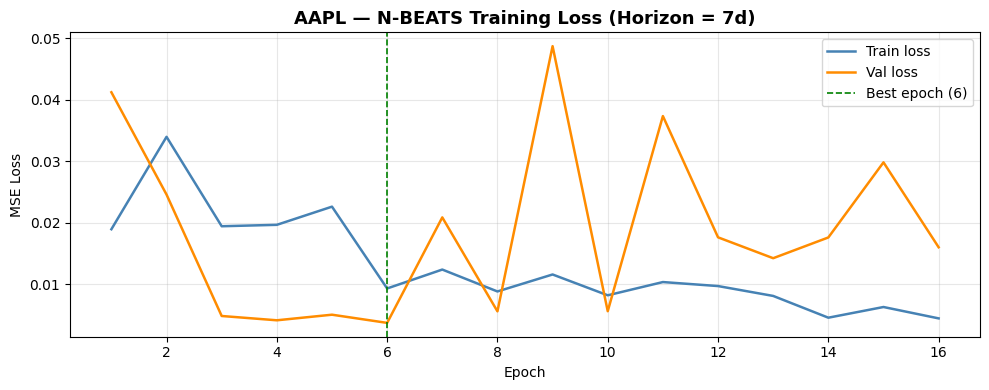

✅ Loss curve plotted | Best epoch: 6 | Best val loss: 0.003712


In [24]:
# Block 16 — Plot training loss curve

fig, ax = plt.subplots(figsize=(10, 4))

epochs_range = range(1, len(train_losses) + 1)
ax.plot(epochs_range, train_losses, color="steelblue",  label="Train loss", linewidth=1.8)
ax.plot(epochs_range, val_losses,   color="darkorange", label="Val loss",   linewidth=1.8)
ax.axvline(x=best_epoch, color="green", linestyle="--", linewidth=1.2,
           label=f"Best epoch ({best_epoch})")

ax.set_title(f"{TICKER} — N-BEATS Training Loss (Horizon = {HORIZON}d)", fontsize=13, fontweight="bold")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE Loss")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print(f"✅ Loss curve plotted | Best epoch: {best_epoch} | Best val loss: {best_val_loss:.6f}")

In [25]:
# Block 17 — Load best checkpoint + run inference on test set

model.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE))
model.eval()
print(f"✅ Loaded best checkpoint from epoch {best_epoch}")

all_preds   = []
all_actuals = []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(DEVICE)
        pred = model(xb)                       # (batch, horizon) — N-BEATS output
        all_preds.append(pred.cpu().numpy())
        all_actuals.append(yb.numpy())

all_preds   = np.concatenate(all_preds,   axis=0)  # (n_test_samples, horizon)
all_actuals = np.concatenate(all_actuals, axis=0)  # (n_test_samples, horizon)

print(f"   Inference complete | Predictions: {all_preds.shape} | Actuals: {all_actuals.shape}")

✅ Loaded best checkpoint from epoch 6
   Inference complete | Predictions: (191, 7) | Actuals: (191, 7)


In [26]:
# Block 18 — Inverse-scale predictions

n_all_cols = len(ALL_COLS)

def inverse_scale_close(scaled_close_vals: np.ndarray) -> np.ndarray:
    """
    scaled_close_vals: (n_samples, horizon)
    returns:           (n_samples, horizon) in original price units
    """
    n, h = scaled_close_vals.shape
    result = np.zeros((n * h, n_all_cols))
    result[:, CLOSE_IDX] = scaled_close_vals.reshape(-1)
    inv = scaler.inverse_transform(result)
    return inv[:, CLOSE_IDX].reshape(n, h)


preds_price   = inverse_scale_close(all_preds)
actuals_price = inverse_scale_close(all_actuals)

pred_day1   = preds_price[:, 0]
actual_day1 = actuals_price[:, 0]

print(f"✅ Inverse-scaling complete")
print(f"   Price range — Actual: [{actual_day1.min():.2f}, {actual_day1.max():.2f}]")
print(f"   Price range — Pred:   [{pred_day1.min():.2f}, {pred_day1.max():.2f}]")

✅ Inverse-scaling complete
   Price range — Actual: [163.36, 251.87]
   Price range — Pred:   [180.01, 239.87]


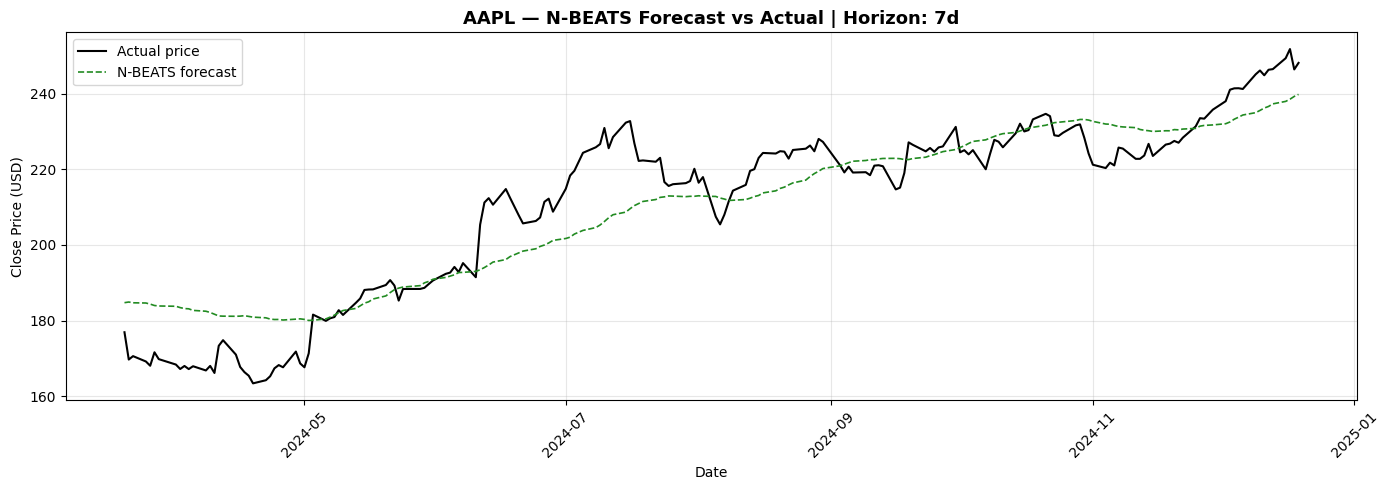

✅ Forecast vs actual plot complete


In [27]:
# Block 19 — Plot forecast vs actual (test set)

test_dates = df_test.index[WINDOW : WINDOW + len(pred_day1)]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(test_dates, actual_day1, color="black",       linewidth=1.5, label="Actual price")
ax.plot(test_dates, pred_day1,   color="forestgreen", linewidth=1.2, linestyle="--",
        label="N-BEATS forecast")

ax.set_title(f"{TICKER} — N-BEATS Forecast vs Actual | Horizon: {HORIZON}d",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Date")
ax.set_ylabel("Close Price (USD)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=45)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print("✅ Forecast vs actual plot complete")

In [28]:
# Block 20 — Compute metrics: MAE, RMSE, MAPE, Directional Accuracy

y_true = actual_day1
y_pred = pred_day1

mae  = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mape = np.mean(np.abs((y_true - y_pred) / np.abs(y_true))) * 100

actual_yesterday = df_test["Close"].values[WINDOW - 1 : WINDOW - 1 + len(y_true)]
da = np.mean(
    np.sign(y_pred - actual_yesterday) == np.sign(y_true - actual_yesterday)
) * 100

metrics = pd.DataFrame({
    "Metric":      ["MAE", "RMSE", "MAPE (%)", "Directional Accuracy (%)"],
    "Value":       [round(mae, 4), round(rmse, 4), round(mape, 4), round(da, 2)],
    "Better when": ["↓ lower", "↓ lower", "↓ lower", "↑ higher"]
})

metrics_path = os.path.join(RESULTS_DIR, "nbeats_metrics.csv")
metrics.to_csv(metrics_path, index=False)

print(f"✅ Test metrics (day-1 forecast, n={len(y_true)} samples):\n")
display(metrics)
print(f"\n💾 Saved → {metrics_path}")

✅ Test metrics (day-1 forecast, n=191 samples):



,Metric,Value,Better when
0,MAE,7.4764,↓ lower
1,RMSE,9.4883,↓ lower
2,MAPE (%),3.6772,↓ lower
3,Directional Accuracy (%),49.2100,↑ higher



💾 Saved → /content/drive/MyDrive/stock_forecasting/results/nbeats_metrics.csv


In [29]:
# Block 21 — Walk-forward backtest

actual_close = df_test["Close"].values

n_bt        = len(pred_day1)
actual_bt   = actual_close[WINDOW     : WINDOW + n_bt]
actual_next = actual_close[WINDOW + 1 : WINDOW + n_bt + 1]
pred_bt     = pred_day1

bah_returns   = (actual_next - actual_bt) / actual_bt
signal        = (pred_bt > actual_bt).astype(float)
model_returns = signal * bah_returns

position_change = np.abs(np.diff(signal, prepend=0.0))
TC = 0.001
model_returns -= position_change * TC

model_equity = np.cumprod(1 + model_returns)
bah_equity   = np.cumprod(1 + bah_returns)

bt_dates = df_test.index[WINDOW : WINDOW + n_bt]

print(f"✅ Backtest complete | {n_bt} trading days | TC = {TC*100:.1f}% per trade")
print(f"   Total trades: {int(position_change.sum())}")
print(f"   Final model equity: {model_equity[-1]:.4f} | Buy-and-hold: {bah_equity[-1]:.4f}")

✅ Backtest complete | 191 trading days | TC = 0.1% per trade
   Total trades: 20
   Final model equity: 1.3133 | Buy-and-hold: 1.4295


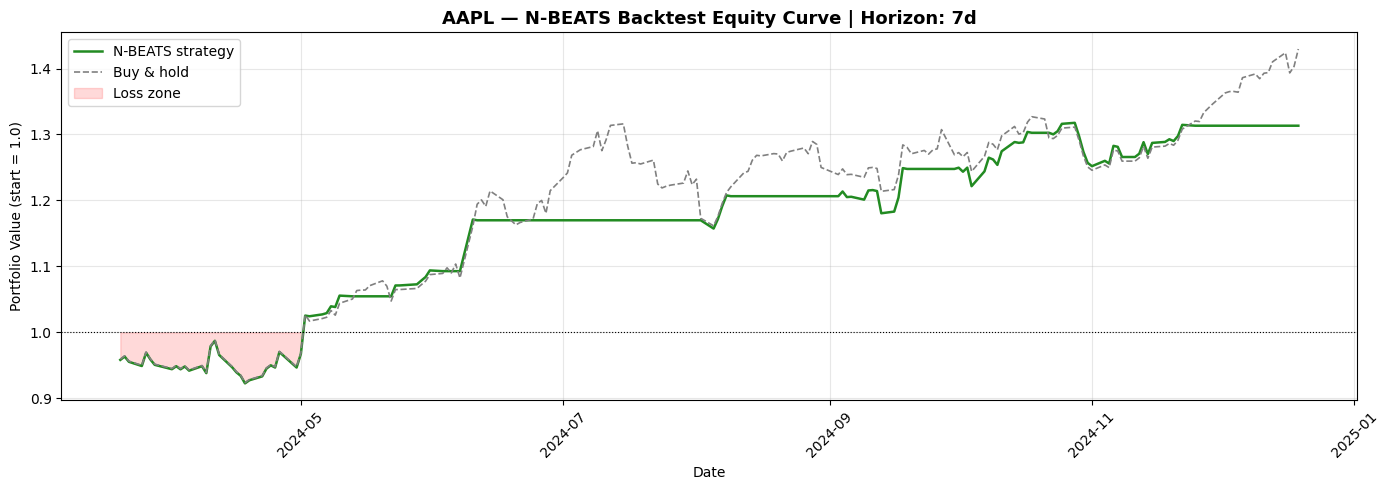

✅ Equity curve plotted


In [30]:
# Block 22 — Plot equity curve (N-BEATS strategy vs buy-and-hold)

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(bt_dates, model_equity, color="forestgreen", linewidth=1.8, label="N-BEATS strategy")
ax.plot(bt_dates, bah_equity,   color="grey",        linewidth=1.2, linestyle="--",
        label="Buy & hold")
ax.axhline(y=1.0, color="black", linewidth=0.8, linestyle=":")
ax.fill_between(bt_dates, model_equity, 1.0,
                where=(model_equity < 1.0), alpha=0.15, color="red", label="Loss zone")

ax.set_title(f"{TICKER} — N-BEATS Backtest Equity Curve | Horizon: {HORIZON}d",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Date")
ax.set_ylabel("Portfolio Value (start = 1.0)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=45)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print("✅ Equity curve plotted")

In [31]:
# Block 23 — Backtest metrics: Sharpe ratio + Max Drawdown

mean_ret = np.mean(model_returns)
std_ret  = np.std(model_returns) + 1e-9
sharpe   = (mean_ret / std_ret) * np.sqrt(252)

peak    = np.maximum.accumulate(model_equity)
max_dd  = ((model_equity - peak) / peak).min() * 100

bah_sharpe = (np.mean(bah_returns) / (np.std(bah_returns) + 1e-9)) * np.sqrt(252)
bah_peak   = np.maximum.accumulate(bah_equity)
bah_max_dd = ((bah_equity - bah_peak) / bah_peak).min() * 100

bt_metrics = pd.DataFrame({
    "Metric":           ["Sharpe Ratio", "Max Drawdown (%)"],
    "N-BEATS Strategy": [round(sharpe, 4), round(max_dd, 2)],
    "Buy & Hold":       [round(bah_sharpe, 4), round(bah_max_dd, 2)]
})

print(f"✅ Backtest metrics:\n")
display(bt_metrics)

✅ Backtest metrics:



,Metric,N-BEATS Strategy,Buy & Hold
0,Sharpe Ratio,2.1001,2.1231
1,Max Drawdown (%),-6.5400,-11.7500


In [32]:
# Block 24 — Save model + scaler to Google Drive

MODEL_PATH  = os.path.join(MODEL_DIR, "nbeats_best.pt")
SCALER_PATH = os.path.join(MODEL_DIR, "nbeats_scaler.joblib")

torch.save(model.state_dict(), MODEL_PATH)
joblib.dump(scaler, SCALER_PATH)

print("✅ Artefacts saved to Google Drive:")
print(f"   Model  → {MODEL_PATH}")
print(f"   Scaler → {SCALER_PATH}")
print(f"\n📋 Reload with:")
print(f"   model.load_state_dict(torch.load('{MODEL_PATH}', map_location=DEVICE))")
print(f"   scaler = joblib.load('{SCALER_PATH}')")
print(f"\n🏁 colab_nbeats.ipynb complete for {TICKER} | Horizon: {HORIZON}d")

✅ Artefacts saved to Google Drive:
   Model  → /content/drive/MyDrive/stock_forecasting/models/nbeats_best.pt
   Scaler → /content/drive/MyDrive/stock_forecasting/models/nbeats_scaler.joblib

📋 Reload with:
   model.load_state_dict(torch.load('/content/drive/MyDrive/stock_forecasting/models/nbeats_best.pt', map_location=DEVICE))
   scaler = joblib.load('/content/drive/MyDrive/stock_forecasting/models/nbeats_scaler.joblib')

🏁 colab_nbeats.ipynb complete for AAPL | Horizon: 7d
